# Brassica XGBoost Model Notebook

In [93]:
# ============================================================
# GLOBAL CONFIGURATION
# Set PAIR, USE_GROUP1, and USE_RECOMB before running.
# These three flags control input data, output paths,
# hyperparameters, and feature handling for all blocks.
#
# Valid PAIR values : "lf_mf1", "lf_mf2", "mf1_mf2"
# USE_GROUP1        : True  = Group I (arm–arm pairs) only
#                     False = full pairwise dataset
# USE_RECOMB        : True  = include recombination rate feature
#                     False = exclude it (ablation study)
# ============================================================

from pathlib import Path

PAIR       = "mf1_mf2"
USE_GROUP1 = True
USE_RECOMB = True

# --- Input paths ---
FEATURESETS_DIR = Path("../final_featuresets")

input_paths = {
    ("lf_mf1",  False): FEATURESETS_DIR / "Brapa_lf_mf1_final.csv",
    ("lf_mf1",  True):  FEATURESETS_DIR / "Brapa_lf_mf1_groupI_final.csv",
    ("lf_mf2",  False): FEATURESETS_DIR / "Brapa_lf_mf2_final.csv",
    ("lf_mf2",  True):  FEATURESETS_DIR / "Brapa_lf_mf2_groupI_final.csv",
    ("mf1_mf2", False): FEATURESETS_DIR / "Brapa_mf1_mf2_final.csv",
    ("mf1_mf2", True):  FEATURESETS_DIR / "Brapa_mf1_mf2_groupI_final.csv",
}

input_path = input_paths[(PAIR, USE_GROUP1)]

# --- Output directory ---
# Mirrored from maize: ablation outputs go to a separate directory
# to prevent mixing with standard model outputs.
# Kept local and regenerable — not tracked in git (see .gitignore).
OUTPUT_DIR = (
    Path("../brassica_outputs/model_outputs")
    if USE_RECOMB else
    Path("../brassica_outputs/model_outputs_no_recomb")
)

# --- Output file prefix ---
_group_tag  = "groupI" if USE_GROUP1 else "all"
_recomb_tag = "" if USE_RECOMB else "_no_recomb"
PREFIX = f"{PAIR}_{_group_tag}{_recomb_tag}"

# --- Feature flags ---
USE_LOCATION = not USE_GROUP1

# --- Subgenome display labels ---
pair_labels = {
    "lf_mf1":  {"sg0": "LF",  "sg1": "MF1", "title": "LF\u2013MF1"},
    "lf_mf2":  {"sg0": "LF",  "sg1": "MF2", "title": "LF\u2013MF2"},
    "mf1_mf2": {"sg0": "MF1", "sg1": "MF2", "title": "MF1\u2013MF2"},
}

SG0_LABEL  = pair_labels[PAIR]["sg0"]
SG1_LABEL  = pair_labels[PAIR]["sg1"]
PAIR_TITLE = pair_labels[PAIR]["title"]

# ============================================================
# RETRAIN_MODEL TOGGLE
# ============================================================
# Set RETRAIN_MODEL = True  the first time you run this notebook,
# or any time you change GROUP, USE_RECOMB, hyperparameters, or
# input data. This runs test_classifier() and saves a checkpoint.
#
# Set RETRAIN_MODEL = False to skip model training entirely and
# load the saved checkpoint instead. All downstream cells (metrics,
# SHAP plots, network figures) will run identically from the loaded
# arrays. No retraining occurs; no checkpoint is overwritten.
#
# The checkpoint file is named {PREFIX}_cv_checkpoint.npz and lives
# in OUTPUT_DIR. It is keyed to the current GROUP and USE_RECOMB
# settings via the PREFIX — changing either requires retraining once.
# ============================================================

RETRAIN_MODEL = False   # <-- set to False once the checkpoint exists

# --- Hyperparameters ---
# Optuna-tuned per (PAIR, USE_GROUP1) combination. Tuned with USE_RECOMB=True;
# the ablation study (USE_RECOMB=False) uses these same tuned values to isolate
# recombination's marginal contribution without re-optimizing — identical to
# the maize approach.
hyperparams = {

    ("lf_mf1", False): dict(
        eval_metric="logloss",
        learning_rate=0.00340492,
        n_estimators=509,
        max_depth=9,
        subsample=0.67350842,
        colsample_bytree=0.67709409,
        min_child_weight=5,
        gamma=3.00069161,
        reg_alpha=3.12349698,
        reg_lambda=6.66792622,
        early_stopping_rounds=30,
    ),

    ("lf_mf1", True): dict(
        eval_metric="logloss",
        learning_rate=0.00209743,
        n_estimators=945,
        max_depth=10,
        subsample=0.68408441,
        colsample_bytree=0.77986648,
        min_child_weight=3,
        gamma=0.49840309,
        reg_alpha=3.28108113,
        reg_lambda=14.94856833,
        early_stopping_rounds=30,
    ),

    ("lf_mf2", False): dict(
        eval_metric="logloss",
        learning_rate=0.00770519,
        n_estimators=672,
        max_depth=10,
        subsample=0.91876744,
        colsample_bytree=0.64560552,
        min_child_weight=1,
        gamma=3.00742435,
        reg_alpha=0.47056693,
        reg_lambda=0.37745439,
        early_stopping_rounds=30,
    ),

    ("lf_mf2", True): dict(
        eval_metric="logloss",
        learning_rate=0.00117151,
        n_estimators=940,
        max_depth=8,
        subsample=0.84514057,
        colsample_bytree=0.64981482,
        min_child_weight=1,
        gamma=0.07678008,
        reg_alpha=0.00653891,
        reg_lambda=0.11383468,
        early_stopping_rounds=30,
    ),

    ("mf1_mf2", False): dict(
        eval_metric="logloss",
        learning_rate=0.00132284,
        n_estimators=423,
        max_depth=8,
        subsample=0.91642639,
        colsample_bytree=0.79863314,
        min_child_weight=1,
        gamma=4.97944929,
        reg_alpha=0.91417920,
        reg_lambda=1.99733246,
        early_stopping_rounds=30,
    ),

    ("mf1_mf2", True): dict(
        eval_metric="logloss",
        learning_rate=0.00558361,
        n_estimators=649,
        max_depth=4,
        subsample=0.79564870,
        colsample_bytree=0.96877832,
        min_child_weight=15,
        gamma=4.99267534,
        reg_alpha=3.50140022,
        reg_lambda=11.58316347,
        early_stopping_rounds=30,
    ),
}

# --- Validate config at startup ---
assert PAIR in ("lf_mf1", "lf_mf2", "mf1_mf2"), \
    f"Invalid PAIR '{PAIR}'. Must be one of: 'lf_mf1', 'lf_mf2', 'mf1_mf2'"
assert isinstance(USE_GROUP1, bool), \
    f"USE_GROUP1 must be True or False, got: {USE_GROUP1}"
assert isinstance(USE_RECOMB, bool), \
    f"USE_RECOMB must be True or False, got: {USE_RECOMB}"
assert (PAIR, USE_GROUP1) in hyperparams, \
    f"No hyperparameters defined for ({PAIR}, {USE_GROUP1}). Check hyperparams dict."

params = hyperparams[(PAIR, USE_GROUP1)]

print(f"PAIR          : {PAIR}")
print(f"USE_GROUP1    : {USE_GROUP1}")
print(f"USE_RECOMB    : {USE_RECOMB}")
print(f"Input path    : {input_path}")
print(f"Output prefix : {PREFIX}")
print(f"Output dir    : {OUTPUT_DIR}")
print(f"Use location  : {USE_LOCATION}")
print(f"SG0 label     : {SG0_LABEL} (dominant,     WGD=0)")
print(f"SG1 label     : {SG1_LABEL} (non-dominant, WGD=1)")

PAIR          : mf1_mf2
USE_GROUP1    : True
USE_RECOMB    : True
Input path    : /blue/meixiazhao/laylaaschuster/brapaGDM/final_brapaMLpreprocess/final_featuresets/Brapa_mf1_mf2_groupI_final.csv
Output prefix : mf1_mf2_groupI
Output dir    : /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs
Use location  : False
SG0 label     : MF1 (dominant,     WGD=0)
SG1 label     : MF2 (non-dominant, WGD=1)


In [94]:
# --- Imports ---
import pandas as pd
import numpy as np
import xgboost as xgb
import shap
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
import seaborn as sns
import networkx as nx

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.metrics import (
    roc_auc_score, roc_curve, auc,
    f1_score, confusion_matrix,
    precision_score, recall_score, accuracy_score
)
from sklearn.preprocessing import label_binarize
from scipy.stats import norm
from statsmodels.stats.multitest import multipletests

OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

In [95]:
# ============================================================
# DATA LOADING AND PREPARATION
# ============================================================

def process_data():
    """
    Loads the feature matrix for the current PAIR and USE_GROUP1
    configuration, separates features (X) and labels (y) by column 
    name, and conditionally excludes 'location' and/or 'recomb' from 
    the feature matrix.

    Exclusion rules (mirrors global flags):
      - 'WGD'      : always excluded — it is the label.
      - 'location' : excluded when USE_LOCATION=False (all groups except "All").
      - 'rec_rate' : excluded when USE_RECOMB=False (ablation study).
    Both 'location' and 'rec_rate' are retained in my_data for traceability
    and downstream inspection regardless of whether they enter the model.

    NaN values are intentionally retained in X:
      - tau:           NaN indicates FPKM = 0 across all tissues (biologically meaningful)
      - upstream_distance/downstream_distance: NaN indicates a chromosome-edge gene with 
      no flanking sequence
    XGBoost handles NaN natively via its missing-value routing at each split.

    Returns
    -------
    my_data       : pd.DataFrame — full dataframe including all columns, for reference
    X             : np.ndarray   — feature matrix
    y             : np.ndarray   — 1D label vector (WGD column)
    feature_names : list         — ordered list of feature names corresponding to X columns
    """

    my_data = pd.read_csv(input_path)

    print(f"Loaded data shape: {my_data.shape}")
    print(f"Columns: {my_data.columns.tolist()}\n")

    # --- Validate expected columns are present in raw data ---
    assert "WGD" in my_data.columns, \
        "CRITICAL: 'WGD' column not found. Check input file."
    assert "location" in my_data.columns, \
        "CRITICAL: 'location' column not found. Check input file."
    assert "rec_rate" in my_data.columns, \
        "CRITICAL: 'rec_rate' column not found. Check input file."

    # --- Define feature columns by name, not position ---
    # Build exclusion set from global flags. Excluded columns are retained
    # in my_data for traceability but do not enter the feature matrix X.
    exclude = {"WGD"}
    if not USE_LOCATION:
        exclude.add("location")
    if not USE_RECOMB:
        exclude.add("rec_rate")

    feature_names = [col for col in my_data.columns if col not in exclude]

    # --- Confirm recomb exclusion when USE_RECOMB=False ---
    if not USE_RECOMB:
        assert "rec_rate" not in feature_names, \
            "CRITICAL: 'rec_rate' found in feature_names despite USE_RECOMB=False. Check exclusion logic."

    print(f"PAIR          : {PAIR}")
    print(f"USE_GROUP1    : {USE_GROUP1}")
    print(f"USE_LOCATION  : {USE_LOCATION}")
    print(f"USE_RECOMB    : {USE_RECOMB}")

    # --- Extract feature matrix and label vector by name ---
    X = my_data[feature_names].to_numpy()
    y = my_data["WGD"].to_numpy()

    # --- Sanity checks ---
    assert X.shape[0] == y.shape[0], \
        f"CRITICAL: Row mismatch — X has {X.shape[0]} rows, y has {y.shape[0]}."
    assert set(np.unique(y)) == {0, 1}, \
        f"CRITICAL: Unexpected label values: {np.unique(y)}. Expected {{0, 1}}."

    unique_labels, counts = np.unique(y, return_counts=True)
    print("Label distribution:")
    for label, count in zip(unique_labels, counts):
        print(f"  WGD={int(label)}: {count} samples")

    nan_report = my_data[feature_names].isna().sum()
    nan_report = nan_report[nan_report > 0]
    if len(nan_report) > 0:
        print("\nNaN values present in feature matrix (retained intentionally):")
        for col, n in nan_report.items():
            print(f"  {col}: {n} NaNs")
    else:
        print("\nNo NaN values in feature matrix.")

    return my_data, X, y, feature_names


# ============================================================
# DATA LOADING — conditional on RETRAIN_MODEL
# ============================================================
# When RETRAIN_MODEL=True:  loads the CSV, builds X, y, feature_names.
# When RETRAIN_MODEL=False: skips loading entirely. feature_names is
#   recovered from the checkpoint in Cell 2. my_data, X, y are not
#   used downstream of test_classifier(), so they are not needed.
# ============================================================

if RETRAIN_MODEL:
    my_data, X, y, feature_names = process_data()
else:
    print("RETRAIN_MODEL=False — skipping process_data().")
    print("feature_names will be restored from checkpoint in Cell 2.")

RETRAIN_MODEL=False — skipping process_data().
feature_names will be restored from checkpoint in Cell 2.


In [96]:
# ============================================================
# CELL 1: test_classifier() FUNCTION DEFINITION
# ============================================================

def test_classifier(X, y, feature_names):
    """
    Runs stratified 10-fold cross-validation with XGBoost.

    Early stopping uses a held-out validation split carved from
    the training fold only. The test fold is never involved in
    any training or stopping decision.

    NaN values in X are passed through untouched — XGBoost routes
    missing values natively at each split.

    Parameters
    ----------
    X            : np.ndarray — feature matrix, shape (n_samples, n_features)
    y            : np.ndarray — binary label vector, shape (n_samples,)
    feature_names: list       — feature names corresponding to columns of X

    Returns
    -------
    true_labels_all    : list  — true labels aggregated across all test folds
    predictions_all    : list  — predicted probabilities for WGD=1, all test folds
    fold_f1_scores     : list  — per-fold F1 score
    fold_train_losses  : list  — per-fold training log loss curve (list of lists)
    fold_val_losses    : list  — per-fold validation log loss curve (list of lists)
                                 Note: these are train/val curves, not train/test.
                                 The val set is carved from the training fold and
                                 is used solely to govern early stopping.
    shap_values_concat    : np.ndarray — SHAP values concatenated across test folds,
                                         shape (n_samples, n_features)
    X_tests_array         : np.ndarray — test fold feature matrices concatenated,
                                         shape (n_samples, n_features)
    shap_interaction_array: np.ndarray — Shapley interaction values concatenated
                                         across test folds,
                                         shape (n_samples, n_features, n_features).
                                         Entry [i, j, k] is the interaction index
                                         between features j and k for sample i.
                                         Diagonal [i, j, j] is feature j's main
                                         effect (contribution independent of other
                                         features) for sample i.
    """

    # --- Cross-validation setup ---
    # Stratified ensures class balance is maintained in every fold
    skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

    # --- Initialize tracking containers ---
    true_labels_all = []         # aggregated true labels across all test folds
    predictions_all = []         # aggregated predicted probabilities across all test folds
    fold_f1_scores  = []         # F1 score for each fold
    fold_auc_scores = []         # AUC score for each fold
    fold_train_losses = []       # training log loss curve per fold
    fold_val_losses   = []       # validation log loss curve per fold (used for early stopping)
    shap_values_list  = []       # SHAP values per fold, concatenated after loop
    shap_interaction_list = []   # Shapley interaction values per fold, concatenated after loop
    X_tests = []                 # test fold arrays, concatenated after loop

    # --- Cross-validation loop ---
    for fold_index, (train_index, test_index) in enumerate(skf.split(X, y)):

        # Outer split: test fold is held out entirely
        X_train_full, X_test = X[train_index], X[test_index]
        y_train_full, y_test = y[train_index], y[test_index]

        # Inner split: carve a validation set from training data only.
        # This validation set governs early stopping and is never used
        # for metric reporting. test_size=0.1 gives ~10% of the training fold.
        X_train, X_val, y_train, y_val = train_test_split(
            X_train_full, y_train_full,
            test_size=0.1,
            random_state=42,
            stratify=y_train_full  # maintain class balance in validation set
        )

        # Fresh classifier instance every fold — no state carried between folds
        classifier = xgb.XGBClassifier(**params)

        # Fit on training data.
        # eval_set: validation_0 = train, validation_1 = val (for early stopping).
        # X_test plays no role here.
        classifier.fit(
            X_train, y_train,
            eval_set=[(X_train, y_train), (X_val, y_val)],
            verbose=False
        )

        # --- Log loss curves ---
        results = classifier.evals_result()
        fold_train_losses.append(results['validation_0']['logloss'])
        fold_val_losses.append(results['validation_1']['logloss'])

        num_epochs = len(results['validation_0']['logloss'])
        print(f"Fold {fold_index + 1:>2}: {num_epochs} boosting rounds")

        # --- Predictions on held-out test fold ---
        # predict_proba uses best_iteration internally — not the final round
        y_pred_proba = classifier.predict_proba(X_test)[:, 1]
        y_pred_binary = (y_pred_proba > 0.5).astype(int)

        # Per-fold F1
        fold_f1 = f1_score(y_test, y_pred_binary)
        fold_f1_scores.append(fold_f1)
        print(f"         F1 = {fold_f1:.3f}")
        
        # Per-fold AUC
        fold_auc = roc_auc_score(y_test, y_pred_proba)
        fold_auc_scores.append(fold_auc)
        print(f"         AUC = {fold_auc:.3f}")

        # Aggregate labels and predictions for across-fold metrics
        true_labels_all.extend(y_test)
        predictions_all.extend(y_pred_proba)

        # Store test fold array for SHAP summary plots
        X_tests.append(X_test)

        # --- SHAP values for this fold ---
        # Explainer is built on X_train for this fold (background data).
        # SHAP values are computed on X_test — the held-out fold.
        # This ensures SHAP attribution reflects generalization, not training fit.
        explainer = shap.TreeExplainer(classifier)
        shap_values = explainer.shap_values(X_test, check_additivity=True)
        shap_values_list.append(shap_values)
        
        # --- True Shapley interaction values for this fold ---
        # Evaluates the model over all feature subsets to measure how much
        # the marginal contribution of feature j changes depending on the
        # value of feature k, for each sample. 
        # Output shape: (n_test_samples, n_features, n_features).
        # Diagonal entry [i, j, j]: feature j's main effect for sample i
        #   (contribution independent of interactions with other features).
        # Off-diagonal entry [i, j, k]: interaction index between features
        #   j and k for sample i. Positive = synergistic, negative = antagonistic.
        # Note: shap_interaction_values() does not accept a check_additivity
        # parameter — it always computes exactly. Do not add that argument.
        shap_interact = explainer.shap_interaction_values(X_test)
        shap_interaction_list.append(shap_interact)

    # --- Concatenate across folds ---
    # Every sample appears exactly once as a test sample across 10 folds
    X_tests_array      = np.concatenate(X_tests, axis=0)
    shap_values_concat = np.concatenate(shap_values_list, axis=0)
    shap_interaction_array = np.concatenate(shap_interaction_list, axis=0)
    # shap_interaction_array shape: (n_total_samples, n_features, n_features)

    print(f"\nX_tests_array shape      : {X_tests_array.shape}")
    print(f"shap_values_concat shape   : {shap_values_concat.shape}")

    return (
        true_labels_all,
        predictions_all,
        fold_f1_scores,
        fold_auc_scores,
        fold_train_losses,
        fold_val_losses,
        shap_values_concat,
        X_tests_array,
        shap_interaction_array
    )

In [97]:
# ============================================================
# CELL 2: RUN THE MODEL — OR LOAD FROM CHECKPOINT
# ============================================================
# RETRAIN_MODEL=True  → runs test_classifier(), then saves all
#   9 return values to {PREFIX}_cv_checkpoint.npz in OUTPUT_DIR.
#   loss curves are NaN-padded to a fixed width for storage and
#   stripped back to ragged lists on load — downstream Plot Cell B
#   re-pads them itself, so restored values are functionally identical.
#
# RETRAIN_MODEL=False → asserts the checkpoint exists (hard error if
#   not), loads it, and reconstructs all 9 variables with the same
#   names and types as test_classifier() would have returned.
#   No fallback to retraining. No silent failures.
# ============================================================

# --- Checkpoint path is keyed to current GROUP and USE_RECOMB via PREFIX ---
# Changing GROUP or USE_RECOMB changes PREFIX, which changes this path,
# which forces a hard error if the new checkpoint doesn't exist yet.
CHECKPOINT_PATH = OUTPUT_DIR / f"{PREFIX}_cv_checkpoint.npz"

if RETRAIN_MODEL:

    # ---------------------------------------------------------
    # TRAIN
    # ---------------------------------------------------------
    (
        true_labels_all,
        predictions_all,
        fold_f1_scores,
        fold_auc_scores,
        fold_train_losses,
        fold_val_losses,
        shap_values_array,
        X_test_array,
        shap_interaction_array
    ) = test_classifier(X, y, feature_names)

    # ---------------------------------------------------------
    # SAVE CHECKPOINT
    # ---------------------------------------------------------
    # fold_train_losses and fold_val_losses are lists of lists with
    # unequal lengths (early stopping gives each fold a different
    # number of boosting rounds). np.savez cannot store ragged arrays,
    # so we NaN-pad each curve to the length of the longest one.
    # The original lengths are stored separately so the padding can be
    # stripped precisely on load, restoring the original ragged structure.

    n_folds = len(fold_train_losses)

    # Compute max curve length across folds (may differ for train vs val)
    max_train_len = max(len(curve) for curve in fold_train_losses)
    max_val_len   = max(len(curve) for curve in fold_val_losses)

    # NaN-pad to uniform width; shape (n_folds, max_len)
    padded_train = np.array([
        np.pad(curve,
               (0, max_train_len - len(curve)),
               mode='constant',
               constant_values=np.nan)
        for curve in fold_train_losses
    ], dtype=np.float32)

    padded_val = np.array([
        np.pad(curve,
               (0, max_val_len - len(curve)),
               mode='constant',
               constant_values=np.nan)
        for curve in fold_val_losses
    ], dtype=np.float32)

    # Record original (pre-padding) lengths so load can strip exactly
    train_curve_lengths = np.array([len(c) for c in fold_train_losses], dtype=np.int32)
    val_curve_lengths   = np.array([len(c) for c in fold_val_losses],   dtype=np.int32)

    np.savez_compressed(
        CHECKPOINT_PATH,

        # --- Aggregated predictions and labels ---
        true_labels_all     = np.array(true_labels_all, dtype=np.int8),
        predictions_all     = np.array(predictions_all, dtype=np.float32),

        # --- Per-fold scalar metrics ---
        fold_f1_scores      = np.array(fold_f1_scores,  dtype=np.float32),
        fold_auc_scores     = np.array(fold_auc_scores, dtype=np.float32),

        # --- Per-fold loss curves (NaN-padded) ---
        fold_train_losses   = padded_train,
        fold_val_losses     = padded_val,
        train_curve_lengths = train_curve_lengths,
        val_curve_lengths   = val_curve_lengths,

        # --- SHAP arrays ---
        shap_values_array       = shap_values_array.astype(np.float32),
        X_test_array            = X_test_array.astype(np.float32),
        shap_interaction_array  = shap_interaction_array.astype(np.float32),

        # --- Feature names (needed when process_data() is skipped) ---
        feature_names = np.array(feature_names),
    )

    print(f"\nCheckpoint saved: {CHECKPOINT_PATH}")
    print(f"  Samples               : {len(true_labels_all)}")
    print(f"  Features              : {len(feature_names)}")
    print(f"  SHAP array shape      : {shap_values_array.shape}")
    print(f"  Interaction array shape: {shap_interaction_array.shape}")
    print(f"  Train curve lengths   : {train_curve_lengths.tolist()}")
    print(f"  Val curve lengths     : {val_curve_lengths.tolist()}")

else:

    # ---------------------------------------------------------
    # LOAD CHECKPOINT
    # ---------------------------------------------------------
    # Hard error if the checkpoint doesn't exist for this GROUP/USE_RECOMB.
    # There is no fallback to retraining — fix the path or set RETRAIN_MODEL=True.
    if not CHECKPOINT_PATH.exists():
        raise FileNotFoundError(
            f"\nRETRAIN_MODEL=False but no checkpoint was found at:\n"
            f"  {CHECKPOINT_PATH}\n\n"
            f"To fix: set RETRAIN_MODEL=True, run Cells 1-2, then set it back to False.\n"
            f"Current GROUP={GROUP!r}, USE_RECOMB={USE_RECOMB!r} → PREFIX={PREFIX!r}"
        )

    print(f"Loading checkpoint: {CHECKPOINT_PATH}")
    ckpt = np.load(CHECKPOINT_PATH, allow_pickle=True)

    # --- Aggregated predictions and labels ---
    # .tolist() restores Python lists to match test_classifier() return types.
    # Downstream cells (Cell 3, XAI Cell 1) call np.array() on these,
    # so list vs array here makes no practical difference.
    true_labels_all = ckpt["true_labels_all"].tolist()
    predictions_all = ckpt["predictions_all"].tolist()

    # --- Per-fold scalar metrics ---
    fold_f1_scores  = ckpt["fold_f1_scores"].tolist()
    fold_auc_scores = ckpt["fold_auc_scores"].tolist()

    # --- Per-fold loss curves: strip NaN padding back to ragged lists ---
    # train_curve_lengths[i] is the number of valid (non-padded) entries
    # in fold i. Slicing to that length removes the NaN padding exactly.
    train_curve_lengths = ckpt["train_curve_lengths"]
    val_curve_lengths   = ckpt["val_curve_lengths"]

    fold_train_losses = [
        ckpt["fold_train_losses"][i, :train_curve_lengths[i]].tolist()
        for i in range(len(train_curve_lengths))
    ]
    fold_val_losses = [
        ckpt["fold_val_losses"][i, :val_curve_lengths[i]].tolist()
        for i in range(len(val_curve_lengths))
    ]

    # --- SHAP arrays (float32, same precision as existing shap_by_label.npz) ---
    shap_values_array      = ckpt["shap_values_array"]
    X_test_array           = ckpt["X_test_array"]
    shap_interaction_array = ckpt["shap_interaction_array"]

    # --- Feature names (restored so XAI cells don't need process_data) ---
    feature_names = ckpt["feature_names"].tolist()

    # --- Sanity checks on loaded arrays ---
    assert shap_values_array.ndim == 2, \
        f"CRITICAL: loaded shap_values_array is not 2D — shape {shap_values_array.shape}"
    assert shap_interaction_array.ndim == 3, \
        f"CRITICAL: loaded shap_interaction_array is not 3D — shape {shap_interaction_array.shape}"
    assert shap_values_array.shape[0] == len(true_labels_all), \
        f"CRITICAL: SHAP row count ({shap_values_array.shape[0]}) != label count ({len(true_labels_all)})"
    assert shap_values_array.shape[1] == len(feature_names), \
        f"CRITICAL: SHAP column count ({shap_values_array.shape[1]}) != feature count ({len(feature_names)})"
    assert shap_interaction_array.shape[0] == shap_values_array.shape[0], \
        "CRITICAL: interaction array sample count does not match SHAP array"

    print(f"Checkpoint loaded successfully.")
    print(f"  Samples               : {len(true_labels_all)}")
    print(f"  Features              : {len(feature_names)}")
    print(f"  Feature names         : {feature_names}")
    print(f"  SHAP array shape      : {shap_values_array.shape}")
    print(f"  Interaction array shape: {shap_interaction_array.shape}")
    print(f"  Folds (F1 scores)     : {[round(f, 4) for f in fold_f1_scores]}")
    print(f"  Folds (AUC scores)    : {[round(a, 4) for a in fold_auc_scores]}")

Loading checkpoint: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_groupI_cv_checkpoint.npz
Checkpoint loaded successfully.
  Samples               : 2034
  Features              : 44
  Feature names         : ['H3K27ac_down', 'H3K27ac_up', 'H3K27ac_genebody', 'H3K27me3_down', 'H3K27me3_up', 'H3K27me3_genebody', 'H3K4me3_down', 'H3K4me3_up', 'H3K4me3_genebody', 'avg_expression', 'tau', 'gene_cds_gc', 'promoter_gc', 'rec_rate', 'te_dist', 'TEGroup_1', 'TEGroup_2', 'TEGroup_3', 'TEGroup_4', 'TEdenseAvgUp', 'TEdenseMaxUp', 'TEdenseAvgDown', 'TEdenseMaxDown', 'CG_up_ave', 'CG_down_ave', 'CG_body_ave', 'CHG_up_ave', 'CHG_down_ave', 'CHG_body_ave', 'CHH_up_ave', 'CHH_down_ave', 'CHH_body_ave', 'CG_up_max', 'CG_down_max', 'CHG_up_max', 'CHG_down_max', 'CHH_up_max', 'CHH_down_max', 'summit_fold_enrichment', 'upstream_distance', 'downstream_distance', 'Ka', 'Ks', 'omega']
  SHAP array shape      : (2034, 44)
  Interaction array shape: (2034, 44, 44)
  Folds (F1 scor

In [98]:
# ============================================================
# CELL 3: METRICS COMPUTATION
# ============================================================

# --- Convert predictions to binary labels at 0.5 threshold ---
y_true        = np.array(true_labels_all)
y_pred_probs  = np.array(predictions_all)
y_pred_binary = (y_pred_probs > 0.5).astype(int)

# --- Confusion matrix ---
cm = confusion_matrix(y_true, y_pred_binary)
print("Confusion matrix:\n", cm)

# sklearn results — computed directly from labels and predictions
# zero_division=0 matches the custom function's divide-by-zero guard

precision_sk = precision_score(y_true, y_pred_binary, zero_division=0)
recall_sk    = recall_score(y_true, y_pred_binary, zero_division=0)
f1_pooled    = f1_score(y_true, y_pred_binary, zero_division=0)
accuracy_sk  = accuracy_score(y_true, y_pred_binary)

# --- Final reported metrics (sklearn) ---
print(f"\n--- Overall Metrics: Group {PAIR} ---")
print(f"Precision : {precision_sk:.4f}")
print(f"Recall    : {recall_sk:.4f}")
print(f"F1        : {f1_pooled:.4f}")
print(f"Accuracy  : {accuracy_sk:.4f}")

###### F1 summary ######

# --- Per-fold F1 summary ---
f1_mean = np.mean(fold_f1_scores)
f1_std  = np.std(fold_f1_scores)
print(f"\nPer-fold F1 — mean: {f1_mean:.4f}, std: {f1_std:.4f}")

f1_mean_df = pd.DataFrame({
    "model": [PREFIX],
    "f1_mean": [f1_mean],
    "f1_std": [f1_std],
    "f1_pooled": [f1_pooled],
})

results_path = OUTPUT_DIR / f"{PREFIX}_f1_mean.csv"
f1_mean_df.to_csv(results_path, index=False)

# --- Per-fold F1 scores ---
fold_f1_df = pd.DataFrame({
    "fold":  list(range(1, len(fold_f1_scores) + 1)),
    "f1":    fold_f1_scores,
    "model": PREFIX
})
fold_f1_df.to_csv(OUTPUT_DIR / f"{PREFIX}_fold_f1.csv", index=False)

# --- ROC curve data (for plotting in Cell C1) ---
fpr, tpr, _  = roc_curve(y_true, y_pred_probs)
roc_auc_pooled = auc(fpr, tpr)
print(f"\nROC AUC (pooled): {roc_auc_pooled:.4f}")

###### AUC summary ######

# --- Per-fold AUC summary ---
roc_auc_mean = np.mean(fold_auc_scores)
roc_auc_std  = np.std(fold_auc_scores)
print(f"Per-fold AUC — mean: {roc_auc_mean:.4f}, std: {roc_auc_std:.4f}")

auc_mean_df = pd.DataFrame({
    "model":          [PREFIX],
    "roc_auc_mean":   [roc_auc_mean],
    "roc_auc_std":    [roc_auc_std],
    "roc_auc_pooled": [roc_auc_pooled]
})
auc_mean_df.to_csv(OUTPUT_DIR / f"{PREFIX}_auc_mean.csv", index=False)

# --- Per-fold AUC scores ---
fold_auc_df = pd.DataFrame({
    "fold":  list(range(1, len(fold_auc_scores) + 1)),
    "auc":   fold_auc_scores,
    "model": PREFIX
})
fold_auc_df.to_csv(OUTPUT_DIR / f"{PREFIX}_fold_auc.csv", index=False)

# --- Sanity check: mean vs pooled comparison ---
print(f"\n--- Mean vs Pooled Sanity Check ---")
print(f"F1   — mean: {f1_mean:.4f}  pooled: {f1_pooled:.4f}  diff: {abs(f1_mean - f1_pooled):.4f}")
print(f"AUC  — mean: {roc_auc_mean:.4f}  pooled: {roc_auc_pooled:.4f}  diff: {abs(roc_auc_mean - roc_auc_pooled):.4f}")

Confusion matrix:
 [[612 405]
 [134 883]]

--- Overall Metrics: Group mf1_mf2 ---
Precision : 0.6856
Recall    : 0.8682
F1        : 0.7662
Accuracy  : 0.7350

Per-fold F1 — mean: 0.7662, std: 0.0254

ROC AUC (pooled): 0.8082
Per-fold AUC — mean: 0.8108, std: 0.0317

--- Mean vs Pooled Sanity Check ---
F1   — mean: 0.7662  pooled: 0.7662  diff: 0.0000
AUC  — mean: 0.8108  pooled: 0.8082  diff: 0.0026


Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_groupI_confusion_matrix.png


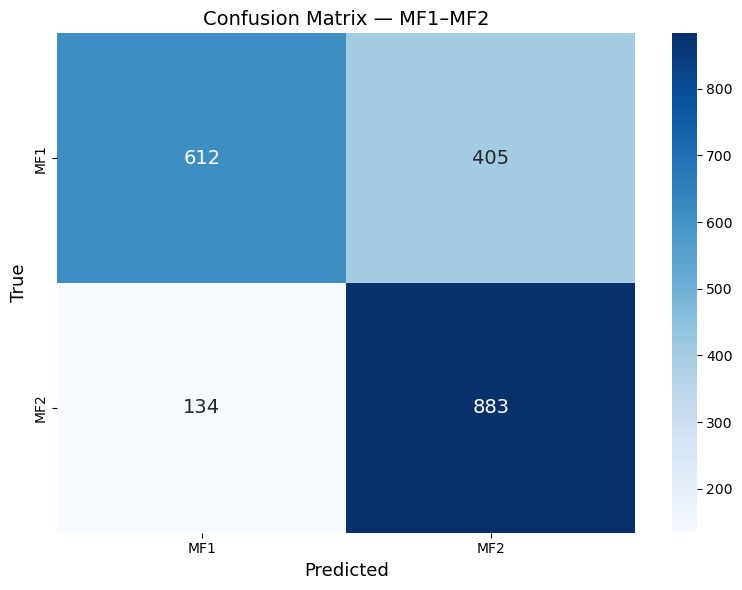

In [99]:
# ============================================================
# PLOT CELL A: CONFUSION MATRIX
# ============================================================

fig, ax = plt.subplots(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[SG0_LABEL, SG1_LABEL],
    yticklabels=[SG0_LABEL, SG1_LABEL],
    annot_kws={"size": 14},
    ax=ax
)

ax.set_xlabel("Predicted", fontsize=13)
ax.set_ylabel("True", fontsize=13)
ax.set_title(f"Confusion Matrix — {PAIR_TITLE}", fontsize=14)

plt.tight_layout()

cm_path = OUTPUT_DIR / f"{PREFIX}_confusion_matrix.png"
plt.savefig(cm_path, bbox_inches='tight', dpi=600)
print(f"Saved: {cm_path}")

plt.show()
plt.close()

Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_groupI_logloss_curves.png


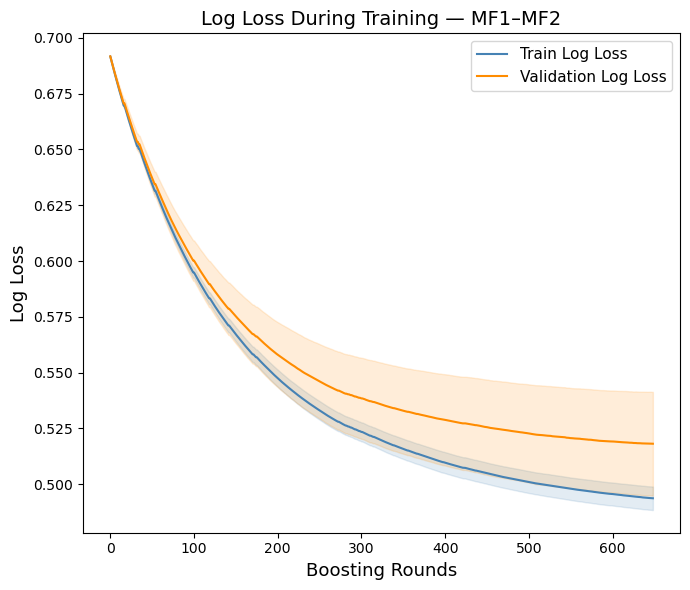

In [100]:
# ============================================================
# PLOT CELL B: LOG LOSS CURVES
# ============================================================
# Shows average training and validation log loss per boosting
# round, averaged across all 10 folds.
# Note: these are train/val curves — the validation set was
# carved from the training fold solely for early stopping.
# This is NOT train/test loss. See methods for distinction.
# ============================================================

# --- Pad loss curves to equal length across folds ---
# Different folds may stop at different boosting rounds due to
# early stopping, producing curves of unequal length.
# NaN-padding allows averaging across folds without bias.
max_epochs = max(len(loss) for loss in fold_train_losses)

padded_train = np.array([
    np.pad(loss, (0, max_epochs - len(loss)), constant_values=np.nan)
    for loss in fold_train_losses
])
padded_val = np.array([
    np.pad(loss, (0, max_epochs - len(loss)), constant_values=np.nan)
    for loss in fold_val_losses
])

# --- Average across folds, ignoring NaN padding ---
avg_train = np.nanmean(padded_train, axis=0)
avg_val   = np.nanmean(padded_val, axis=0)
std_train = np.nanstd(padded_train, axis=0)
std_val   = np.nanstd(padded_val, axis=0)

boosting_rounds = np.arange(max_epochs)

fig, ax = plt.subplots(figsize=(7, 6))

# Plot mean loss curves
ax.plot(boosting_rounds, avg_train, label="Train Log Loss",      color="steelblue")
ax.plot(boosting_rounds, avg_val,   label="Validation Log Loss", color="darkorange")

# Shaded bands show ± 1 std across folds
ax.fill_between(boosting_rounds,
                avg_train - std_train,
                avg_train + std_train,
                alpha=0.15, color="steelblue")
ax.fill_between(boosting_rounds,
                avg_val - std_val,
                avg_val + std_val,
                alpha=0.15, color="darkorange")

ax.set_title(f"Log Loss During Training — {PAIR_TITLE}", fontsize=14)
ax.set_xlabel("Boosting Rounds", fontsize=13)
ax.set_ylabel("Log Loss", fontsize=13)
ax.legend(fontsize=11)

plt.tight_layout()

logloss_path = OUTPUT_DIR / f"{PREFIX}_logloss_curves.png"
plt.savefig(logloss_path, bbox_inches='tight', dpi=600)
print(f"Saved: {logloss_path}")

plt.show()
plt.close()

Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_groupI_roc_data.csv
Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_groupI_roc_curve.png


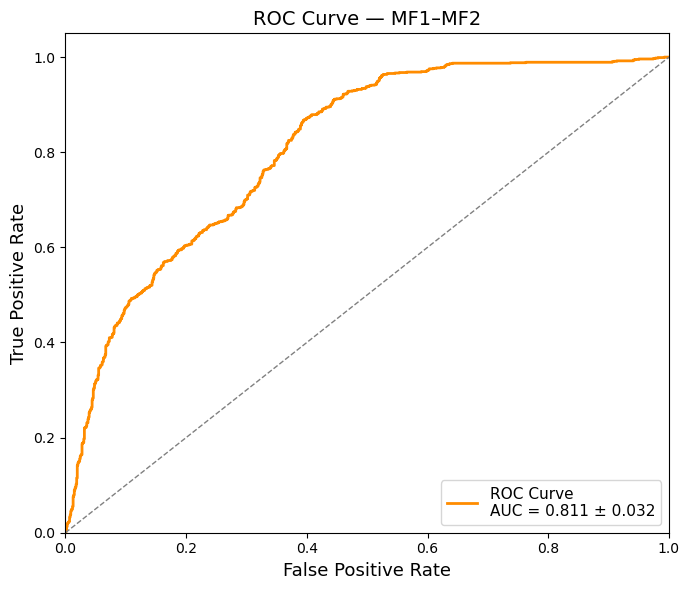

In [101]:
# ============================================================
# PLOT CELL C1: ROC CURVE
# ============================================================

roc_df = pd.DataFrame({
    "fpr":   fpr,
    "tpr":   tpr,
    "model": PREFIX,
    "auc":   roc_auc_pooled
})

roc_data_path = OUTPUT_DIR / f"{PREFIX}_roc_data.csv"
roc_df.to_csv(roc_data_path, index=False)
print(f"Saved: {roc_data_path}")

# --- Predicted probabilities and true labels ---
probas_df = pd.DataFrame({
    "true_label": true_labels_all,
    "pred_proba": predictions_all,
    "model":      PREFIX
})
probas_df.to_csv(OUTPUT_DIR / f"{PREFIX}_predicted_probas.csv", index=False)

fig, ax = plt.subplots(figsize=(7, 6))

ax.plot(
    fpr, tpr,
    color="darkorange",
    lw=2,
    label=f"ROC Curve\nAUC = {roc_auc_mean:.3f} ± {roc_auc_std:.3f}"
)
ax.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)

ax.set_xlim([0.0, 1.0])
ax.set_ylim([0.0, 1.05])
ax.set_xlabel("False Positive Rate", fontsize=13)
ax.set_ylabel("True Positive Rate", fontsize=13)
ax.set_title(f"ROC Curve — {PAIR_TITLE}", fontsize=14)
ax.legend(loc="lower right", fontsize=11)

plt.tight_layout()

roc_fig_path = OUTPUT_DIR / f"{PREFIX}_roc_curve.png"
plt.savefig(roc_fig_path, bbox_inches='tight', dpi=600)
print(f"Saved: {roc_fig_path}")

plt.show()
plt.close()

Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_groupI_f1_bar.png


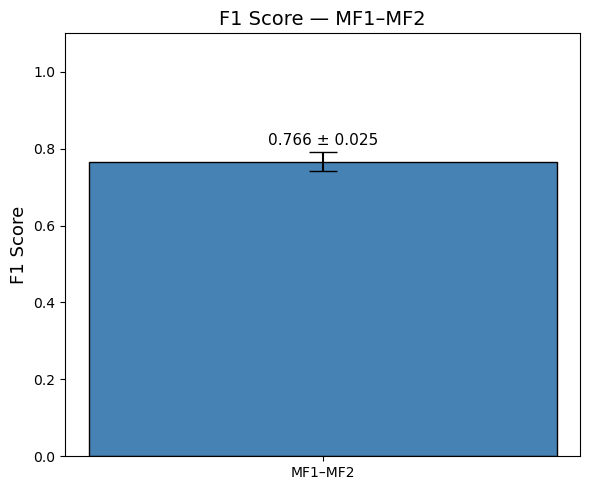

In [102]:
# ============================================================
# PLOT CELL C2: F1 BAR CHART
# ============================================================

fig, ax = plt.subplots(figsize=(6, 5))

ax.bar(
    PAIR_TITLE,
    f1_mean,
    yerr=f1_std,
    capsize=10,
    color="steelblue",
    edgecolor="black",
    width=0.4
)

# Annotate bar with mean ± CV std
ax.text(
    0, f1_mean + f1_std + 0.01,
    f"{f1_mean:.3f} ± {f1_std:.3f}",
    ha="center", va="bottom", fontsize=11
)

ax.set_ylim(0, 1.1)
ax.set_ylabel("F1 Score", fontsize=13)
ax.set_title(f"F1 Score — {PAIR_TITLE}", fontsize=14)

plt.tight_layout()

f1_path = OUTPUT_DIR / f"{PREFIX}_f1_bar.png"
plt.savefig(f1_path, bbox_inches='tight', dpi=600)
print(f"Saved: {f1_path}")

plt.show()
plt.close()

## SHAP Analysis

### SHAP Setup

In [103]:
# ============================================================
# XAI CELL 1: SHAP SETUP — LABEL SPLIT, VALIDATION, SAVE
# ============================================================
# Reconstructs per-label SHAP arrays from cross-validation
# output. shap_values_array rows correspond to test-fold
# samples in the order they were collected across folds;
# true_labels_all contains the matching labels in that same
# order. These must be used together — do not substitute the
# full-dataset y from process_data() here.
# ============================================================

# --- Reconstruct label vector aligned to SHAP rows ---
y_shap = np.asarray(true_labels_all).ravel()
shap_vals = np.asarray(shap_values_array)

# --- Sanity checks ---
assert shap_vals.ndim == 2, \
    f"CRITICAL: shap_vals must be 2D, got shape {shap_vals.shape}"
assert shap_vals.shape[0] == y_shap.shape[0], \
    f"CRITICAL: Row mismatch — SHAP has {shap_vals.shape[0]} rows, " \
    f"labels have {y_shap.shape[0]}."
assert shap_vals.shape[1] == len(feature_names), \
    f"CRITICAL: Feature count mismatch — SHAP has {shap_vals.shape[1]} " \
    f"columns, feature_names has {len(feature_names)}."
assert set(np.unique(y_shap)) == {0, 1}, \
    f"CRITICAL: Unexpected label values in y_shap: {np.unique(y_shap)}"

print(f"SHAP array shape      : {shap_vals.shape}")
print(f"Label vector shape    : {y_shap.shape}")
print(f"WGD=0 ({SG0_LABEL}/dominant)  : {(y_shap == 0).sum()} samples")
print(f"WGD=1 ({SG1_LABEL}/non-dominant): {(y_shap == 1).sum()} samples")

# --- Split SHAP values by subgenome label ---
# shap_label0: SHAP values for WGD=0 genes (dominant subgenome, {SG0_LABEL})
# shap_label1: SHAP values for WGD=1 genes (non-dominant subgenome, {SG1_LABEL})
# Biological motivation: features driving dominant vs. submissive classification
# may be asymmetric — this is a core question in subgenome dominance research.

mask0 = (y_shap == 0)
mask1 = (y_shap == 1)

shap_label0 = shap_vals[mask0]
shap_label1 = shap_vals[mask1]

print(f"\nshap_label0 shape ({SG0_LABEL}): {shap_label0.shape}")
print(f"shap_label1 shape ({SG1_LABEL}): {shap_label1.shape}")

# --- Save per-label SHAP values as CSVs ---
shap_df_label0 = pd.DataFrame(shap_label0, columns=feature_names)
shap_df_label1 = pd.DataFrame(shap_label1, columns=feature_names)

path_label0_csv = OUTPUT_DIR / f"{PREFIX}_shap_label0.csv"
path_label1_csv = OUTPUT_DIR / f"{PREFIX}_shap_label1.csv"

shap_df_label0.to_csv(path_label0_csv, index=False)
shap_df_label1.to_csv(path_label1_csv, index=False)
print(f"\nSaved: {path_label0_csv}")
print(f"Saved: {path_label1_csv}")

# --- Save per-label SHAP values as compressed .npz ---
# Stores the full SHAP array alongside per-label splits, feature names,
# and per-label sample counts in one file for efficient downstream loading.
# shap_all: full test-fold SHAP array (all samples, both labels)
# shap_label0: SHAP values for WGD=0 samples (dominant subgenome, {SG0_LABEL})
# shap_label1: SHAP values for WGD=1 samples (non-dominant subgenome, {SG1_LABEL})
# This file is loaded by the networks notebook for heatmap and network analysis.
path_npz = OUTPUT_DIR / f"{PREFIX}_shap_by_label.npz"

# --- Validate interaction array before save ---
# shap_interaction_array is returned from test_classifier() and unpacked
# in Cell 2. Validated here alongside the 2D SHAP array for consistency.
assert shap_interaction_array.ndim == 3, (
    f"CRITICAL: shap_interaction_array must be 3D, "
    f"got {shap_interaction_array.ndim}D."
)
assert shap_interaction_array.shape[0] == shap_vals.shape[0], (
    f"CRITICAL: Interaction array sample count "
    f"({shap_interaction_array.shape[0]}) does not match "
    f"SHAP array ({shap_vals.shape[0]})."
)
assert shap_interaction_array.shape[1] == shap_interaction_array.shape[2], (
    "CRITICAL: Interaction array feature dimensions are not square."
)
assert shap_interaction_array.shape[1] == len(feature_names), (
    f"CRITICAL: Interaction array feature dim "
    f"({shap_interaction_array.shape[1]}) does not match "
    f"feature_names ({len(feature_names)})."
)
print(f"shap_interaction_array shape  : {shap_interaction_array.shape}")

np.savez_compressed(
    path_npz,
    shap_all             = shap_vals.astype(np.float32),
    shap_label0          = shap_label0.astype(np.float32),
    shap_label1          = shap_label1.astype(np.float32),
    shap_interaction_all = shap_interaction_array.astype(np.float32),
    true_labels          = y_shap.astype(np.int8),
    feature_names        = np.asarray(feature_names),
    counts               = np.array([mask0.sum(), mask1.sum()])
)
print(f"Saved: {path_npz}")

SHAP array shape      : (2034, 44)
Label vector shape    : (2034,)
WGD=0 (MF1/dominant)  : 1017 samples
WGD=1 (MF2/non-dominant): 1017 samples

shap_label0 shape (MF1): (1017, 44)
shap_label1 shape (MF2): (1017, 44)

Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_groupI_shap_label0.csv
Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_groupI_shap_label1.csv
shap_interaction_array shape  : (2034, 44, 44)
Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_groupI_shap_by_label.npz


### Feature Definitions

In [104]:
# ============================================================
# XAI CELL 2: FEATURE DEFINITIONS — RENAME DICT, GROUPS, COLORS
# ============================================================
# All downstream XAI cells reference these dictionaries.
# Do not redefine feature_rename_dict, feature_groups,
# feature_to_group, group_to_color, or renamed_feature_names
# anywhere else in this notebook.
#
# Feature names reflect the brassica preprocessing output.
# See brapaMLpreprocess_Final_genepairs.ipynb for full column
# provenance. 45 features total across 8 categories.
# Note: brassica has 3 histone marks (vs 8 in maize) and
# per-gene Ka/Ks/omega vs Arabidopsis (not pair-specific).
# ============================================================

# --- Short display names for all features ---
# Used on all XAI plots for consistency and readability.
# Keys are exact column names from preprocessing output.
feature_rename_dict = {
    # Location
    'location':                 'Loc',
    # GC content
    'gene_cds_gc':              'GCd',
    'promoter_gc':              'GCp',
    # Expression
    'avg_expression':           'Exp',
    'tau':                      '\u03C4',    # Greek tau — tissue specificity index
    # Evolutionary pressure
    'Ka':                       'Ka',
    'Ks':                       'Ks',
    'omega':                    '\u03C9',    # Greek omega (Ka/Ks ratio)
    # ACR
    'upstream_distance':        'ACRdu',
    'downstream_distance':      'ACRdd',
    'summit_fold_enrichment':   'ACRs',
    # Recombination
    'rec_rate':                 'Re',
    # Methylation — average (9)
    'CHH_up_ave':               'M1',
    'CHH_down_ave':             'M2',
    'CHH_body_ave':             'M3',
    'CHG_up_ave':               'M4',
    'CHG_down_ave':             'M5',
    'CHG_body_ave':             'M6',
    'CG_up_ave':                'M7',
    'CG_down_ave':              'M8',
    'CG_body_ave':              'M9',
    # Methylation — max upstream/downstream only, no body max (6)
    'CHH_up_max':               'M10',
    'CHH_down_max':             'M11',
    'CHG_up_max':               'M12',
    'CHG_down_max':             'M13',
    'CG_up_max':                'M14',
    'CG_down_max':              'M15',
    # TE
    'te_dist':                  'TEdi',
    'TEdenseAvgUp':             'TEu1',
    'TEdenseAvgDown':           'TEd1',
    'TEdenseMaxUp':             'TEu2',
    'TEdenseMaxDown':           'TEd2',
    'TEGroup_1':                'TE1',      # RC/Helitron
    'TEGroup_2':                'TE2',      # DNA transposons
    'TEGroup_3':                'TE3',      # LTR retrotransposons
    'TEGroup_4':                'TE4',      # Non-LTR retrotransposons
    # Histone modifications — 3 marks × 3 regions
    'H3K27ac_down':             'Hd5',
    'H3K27me3_down':            'Hd6',
    'H3K4me3_down':             'Hd3',
    'H3K27ac_genebody':         'Hg5',
    'H3K27me3_genebody':        'Hg6',
    'H3K4me3_genebody':         'Hg3',
    'H3K27ac_up':               'Hu5',
    'H3K27me3_up':              'Hu6',
    'H3K4me3_up':               'Hu3',
}

# --- Feature group membership ---
# Used for color-coding in bar charts and network node coloring.
# 'location' is included here for color assignment but will only
# appear in plots when USE_LOCATION=True (USE_GROUP1=False).
# Features absent from the active feature_names are ignored silently.
feature_groups = {
    'ACR': [
        'upstream_distance', 'downstream_distance', 'summit_fold_enrichment',
    ],
    'Methylation': [
        'CHH_up_ave',  'CHH_down_ave',  'CHH_body_ave',
        'CHG_up_ave',  'CHG_down_ave',  'CHG_body_ave',
        'CG_up_ave',   'CG_down_ave',   'CG_body_ave',
        'CHH_up_max',  'CHH_down_max',
        'CHG_up_max',  'CHG_down_max',
        'CG_up_max',   'CG_down_max',
    ],
    'TE': [
        'TEdenseAvgUp', 'TEdenseAvgDown',
        'TEdenseMaxUp', 'TEdenseMaxDown',
        'TEGroup_1', 'TEGroup_2', 'TEGroup_3', 'TEGroup_4',
        'te_dist',
    ],
    'Histone Modifications Downstream': [
        'H3K27ac_down', 'H3K27me3_down', 'H3K4me3_down',
    ],
    'Histone Modifications Genebody': [
        'H3K27ac_genebody', 'H3K27me3_genebody', 'H3K4me3_genebody',
    ],
    'Histone Modifications Upstream': [
        'H3K27ac_up', 'H3K27me3_up', 'H3K4me3_up',
    ],
    'Recombination':         ['rec_rate'],
    'Evolutionary Pressure': ['Ka', 'Ks', 'omega'],
    'Location':              ['location'],
    'GC Content':            ['gene_cds_gc', 'promoter_gc'],
    'Expression':            ['avg_expression', 'tau'],
}

# --- Derived lookups (do not edit below this line) ---

# Maps each feature name to its group label
feature_to_group = {
    feature: group
    for group, features in feature_groups.items()
    for feature in features
}

# Assigns one color per group — consistent across all XAI plots
_n_groups    = len(feature_groups)
_group_cmap  = plt.colormaps['tab20b'](np.linspace(0, 1, _n_groups))
group_to_color = {
    group: color
    for group, color in zip(feature_groups.keys(), _group_cmap)
}

# Short display names for the active feature set, in column order
# Derived from the live feature_names list — never hardcoded
renamed_feature_names = [
    feature_rename_dict.get(f, f) for f in feature_names
]

# --- Validation: warn if any active feature is missing from rename dict ---
missing = [f for f in feature_names if f not in feature_rename_dict]
if missing:
    print(f"WARNING: {len(missing)} feature(s) not in feature_rename_dict "
          f"— will display raw column name on plots:")
    for f in missing:
        print(f"  {f}")
else:
    print(f"Feature rename dict validated: all {len(feature_names)} "
          f"active features have short names.")

# --- Summary ---
print(f"\nActive features     : {len(feature_names)}")
print(f"Groups defined      : {len(feature_groups)}")
print(f"USE_LOCATION        : {USE_LOCATION}")
if not USE_LOCATION:
    print("  → 'location' / 'Loc' will not appear in this model's plots")

Feature rename dict validated: all 44 active features have short names.

Active features     : 44
Groups defined      : 11
USE_LOCATION        : False
  → 'location' / 'Loc' will not appear in this model's plots


### Feature Importance Proportion

In [105]:
# ============================================================
# XAI CELL 3: FEATURE IMPORTANCE PROPORTION
# ============================================================
# Computes each feature's share of total absolute SHAP
# importance, expressed as a percentage. This is a normalized
# summary of mean absolute SHAP magnitude across all test-fold
# samples. It does not distinguish direction (positive vs.
# negative SHAP) — use the summary dot plots for that.
#
# Uses shap_vals (all samples, both labels) from XAI Cell 1.
# ============================================================

# --- Sum of absolute SHAP values across all samples per feature ---
# Shape: (n_features,)
# Each entry is the total absolute SHAP contribution of that
# feature summed across every test-fold sample.
shap_abs_sum     = np.sum(np.abs(shap_vals), axis=0)
total_shap_value = np.sum(shap_abs_sum)

assert shap_abs_sum.shape[0] == len(feature_names), \
    "CRITICAL: shap_abs_sum length does not match feature_names."
assert total_shap_value > 0, \
    "CRITICAL: Total absolute SHAP value is zero — check shap_vals."

# --- Compute percentage contribution per feature ---
feature_proportions = (shap_abs_sum / total_shap_value) * 100

# --- Build summary DataFrame ---
importance_df = pd.DataFrame({
    'feature':      feature_names,
    'short_name':   renamed_feature_names,
    'abs_shap_sum': shap_abs_sum,
    'pct_total':    feature_proportions.round(2),
}).sort_values(by='pct_total', ascending=False).reset_index(drop=True)

# --- Print top 10 for quick inspection ---
print(f"Total absolute SHAP value: {total_shap_value:.4f}")
print(f"\nTop 10 features by SHAP importance proportion ({PAIR_TITLE}):")
print(importance_df[['short_name', 'pct_total']].head(10).to_string(index=False))

# --- Save full table ---
importance_path = OUTPUT_DIR / f"{PREFIX}_shap_importance_proportion.csv"
importance_df.to_csv(importance_path, index=False)
print(f"\nSaved: {importance_path}")

# --- Display full table in notebook ---
display(importance_df)

Total absolute SHAP value: 2321.6619

Top 10 features by SHAP importance proportion (MF1–MF2):
short_name  pct_total
        Re  83.940002
        Ks   2.370000
      TEd1   1.390000
        M8   1.350000
       Hu6   1.240000
     ACRdu   1.050000
       Hu3   0.660000
      TEu1   0.640000
       Hd5   0.580000
       Hd3   0.510000

Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_groupI_shap_importance_proportion.csv


,feature,short_name,abs_shap_sum,pct_total
0,rec_rate,Re,1948.746216,83.940002
1,Ks,Ks,55.107990,2.370000
2,TEdenseAvgDown,TEd1,32.371571,1.390000
3,CG_down_ave,M8,31.317373,1.350000
4,H3K27me3_up,Hu6,28.747169,1.240000
5,upstream_distance,ACRdu,24.407169,1.050000
6,H3K4me3_up,Hu3,15.283055,0.660000
7,TEdenseAvgUp,TEu1,14.801535,0.640000
8,H3K27ac_down,Hd5,13.401765,0.580000
9,H3K4me3_down,Hd3,11.906368,0.510000


### Aggregate SHAP Summary Plot (Beeswarm)

/scratch/local/31986664/ipykernel_1161982/3612054784.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_groupI_shap_summary_all.png


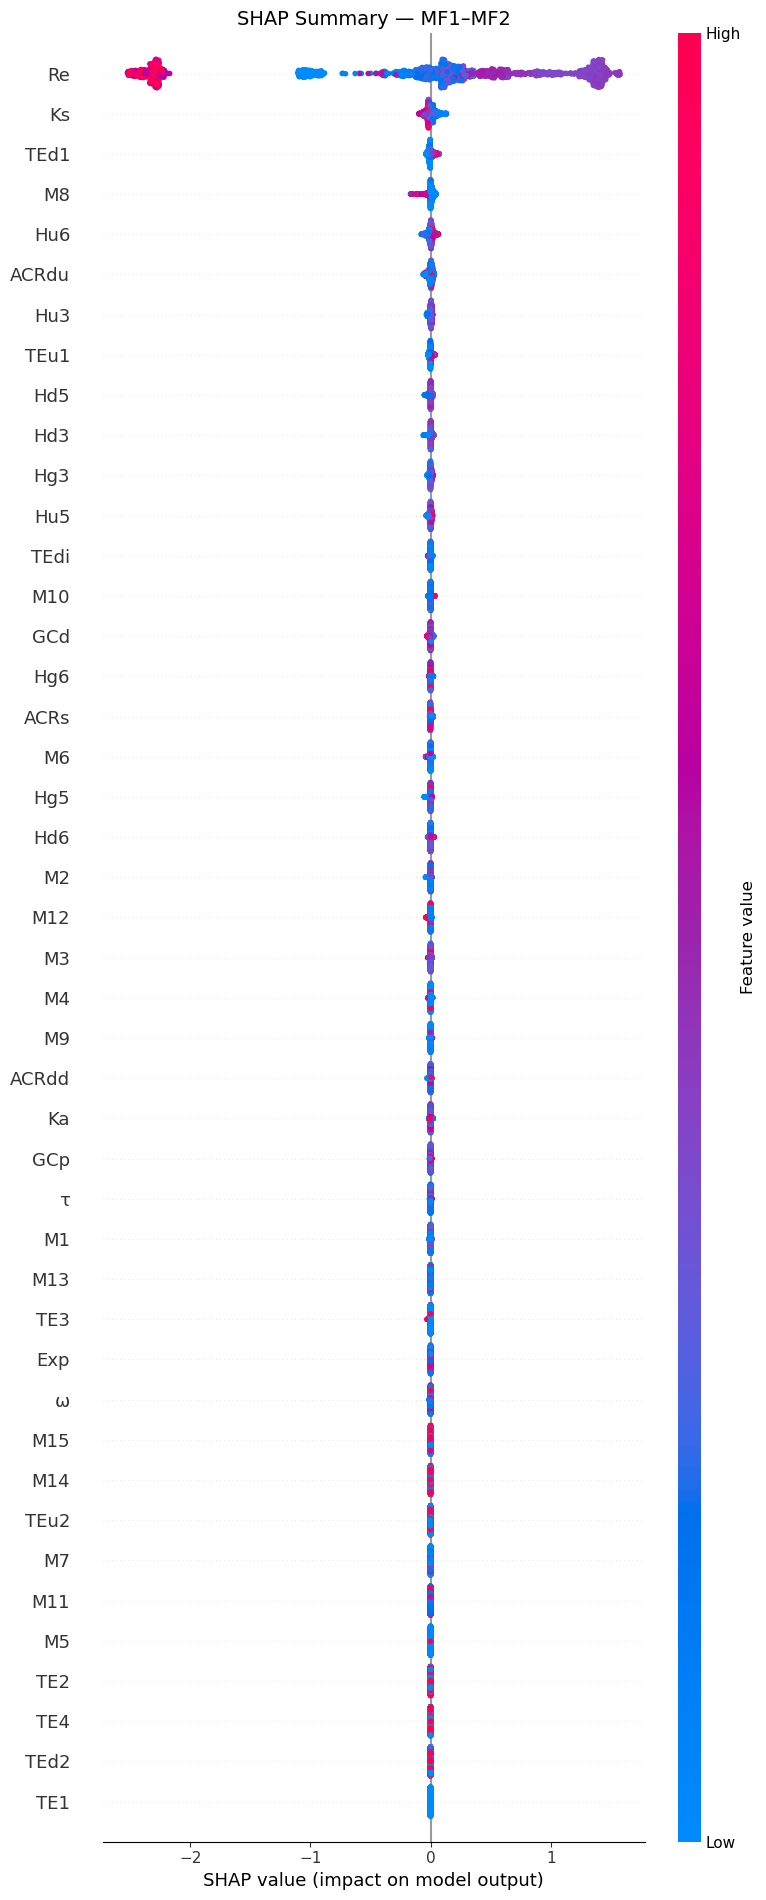

In [106]:
# ============================================================
# XAI CELL 4: SHAP SUMMARY PLOT — ALL SAMPLES (BEESWARM)
# ============================================================
# Beeswarm plot of SHAP values across all test-fold samples.
# Each row is a feature (ranked by mean absolute SHAP, high
# to low). Each dot is one sample; color encodes feature value
# (red = high, blue = low). Horizontal position encodes the
# SHAP value (impact on model output).
#
# This plot reflects classification of both WGD=0
# (dominant) and WGD=1 ( submissive) samples together.
# Per-label beeswarm plots are in XAI Cell 5.
#
# Note: shap.summary_plot() is called with a raw numpy array.
# The array interface defaults to the beeswarm plot type and
# does not accept an explicit plot_type argument — that
# argument is only supported via the Explanation object API.
# ============================================================

fig_summary_all = plt.figure()

shap.summary_plot(
    shap_vals,
    X_test_array,
    feature_names  = renamed_feature_names,
    max_display    = len(feature_names),
    show           = False,
)

plt.title(f"SHAP Summary — {PAIR_TITLE}", fontsize=14)
plt.tight_layout()

summary_all_path = OUTPUT_DIR / f"{PREFIX}_shap_summary_all.png"
plt.savefig(summary_all_path, bbox_inches='tight', dpi=600)
print(f"Saved: {summary_all_path}")

plt.show()
plt.close()

/scratch/local/31986664/ipykernel_1161982/1928415118.py:31: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_groupI_shap_summary_all_no_title.png


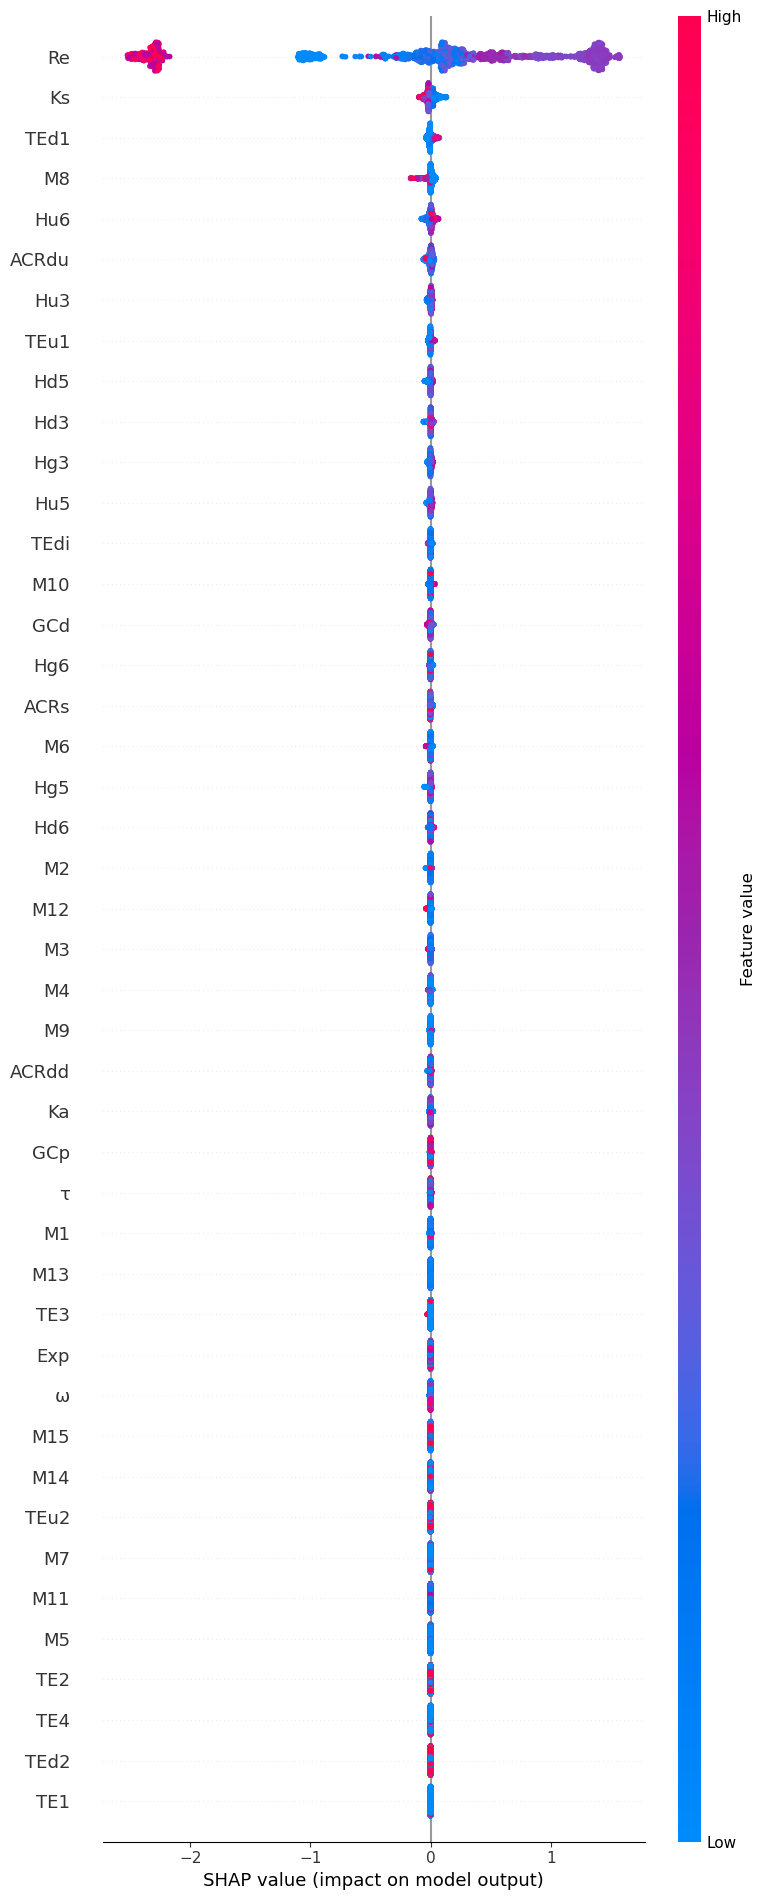

In [107]:
# ============================================================
# XAI CELL 4: SHAP SUMMARY PLOT — ALL SAMPLES (BEESWARM)
# ============================================================
# Beeswarm plot of SHAP values across all test-fold samples.
# Each row is a feature (ranked by mean absolute SHAP, high
# to low). Each dot is one sample; color encodes feature value
# (red = high, blue = low). Horizontal position encodes the
# SHAP value (impact on model output).
#
# This plot reflects classification of both WGD=0
# (dominant) and WGD=1 ( submissive) samples together.
# Per-label beeswarm plots are in XAI Cell 5.
#
# Note: shap.summary_plot() is called with a raw numpy array.
# The array interface defaults to the beeswarm plot type and
# does not accept an explicit plot_type argument — that
# argument is only supported via the Explanation object API.
# ============================================================

fig_summary_all = plt.figure()

shap.summary_plot(
    shap_vals,
    X_test_array,
    feature_names  = renamed_feature_names,
    max_display    = len(feature_names),
    show           = False,
)

# plt.title(f"SHAP Summary — {PAIR_TITLE}", fontsize=14)
plt.tight_layout()

summary_all_path = OUTPUT_DIR / f"{PREFIX}_shap_summary_all_no_title.png"
plt.savefig(summary_all_path, bbox_inches='tight', dpi=600)
print(f"Saved: {summary_all_path}")

plt.show()
plt.close()

/scratch/local/31986664/ipykernel_1161982/2226561569.py:14: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_groupI_shap_summary_top15.png


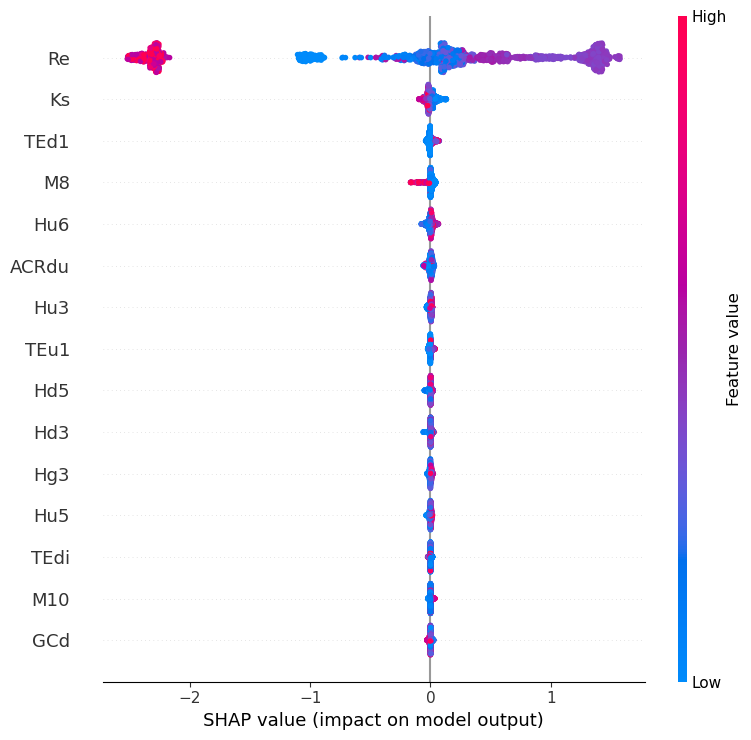

In [108]:
# ----- Top 15 SHAP Beeswarm Plot ----- #

fig_summary_top15 = plt.figure()

shap.summary_plot(
    shap_vals,
    X_test_array,
    feature_names  = renamed_feature_names,
    max_display    = 15,
    show           = False,
)

plt.tight_layout()

summary_top15_path = OUTPUT_DIR / f"{PREFIX}_shap_summary_top15.png"
plt.savefig(summary_top15_path, bbox_inches='tight', dpi=600)
print(f"Saved: {summary_top15_path}")

plt.show()
plt.close()

### Per-Label SHAP Summary Plot (Side-by-Side Beeswarm Panel)

/scratch/local/31986664/ipykernel_1161982/558357326.py:40: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_groupI_shap_summary_label0.png


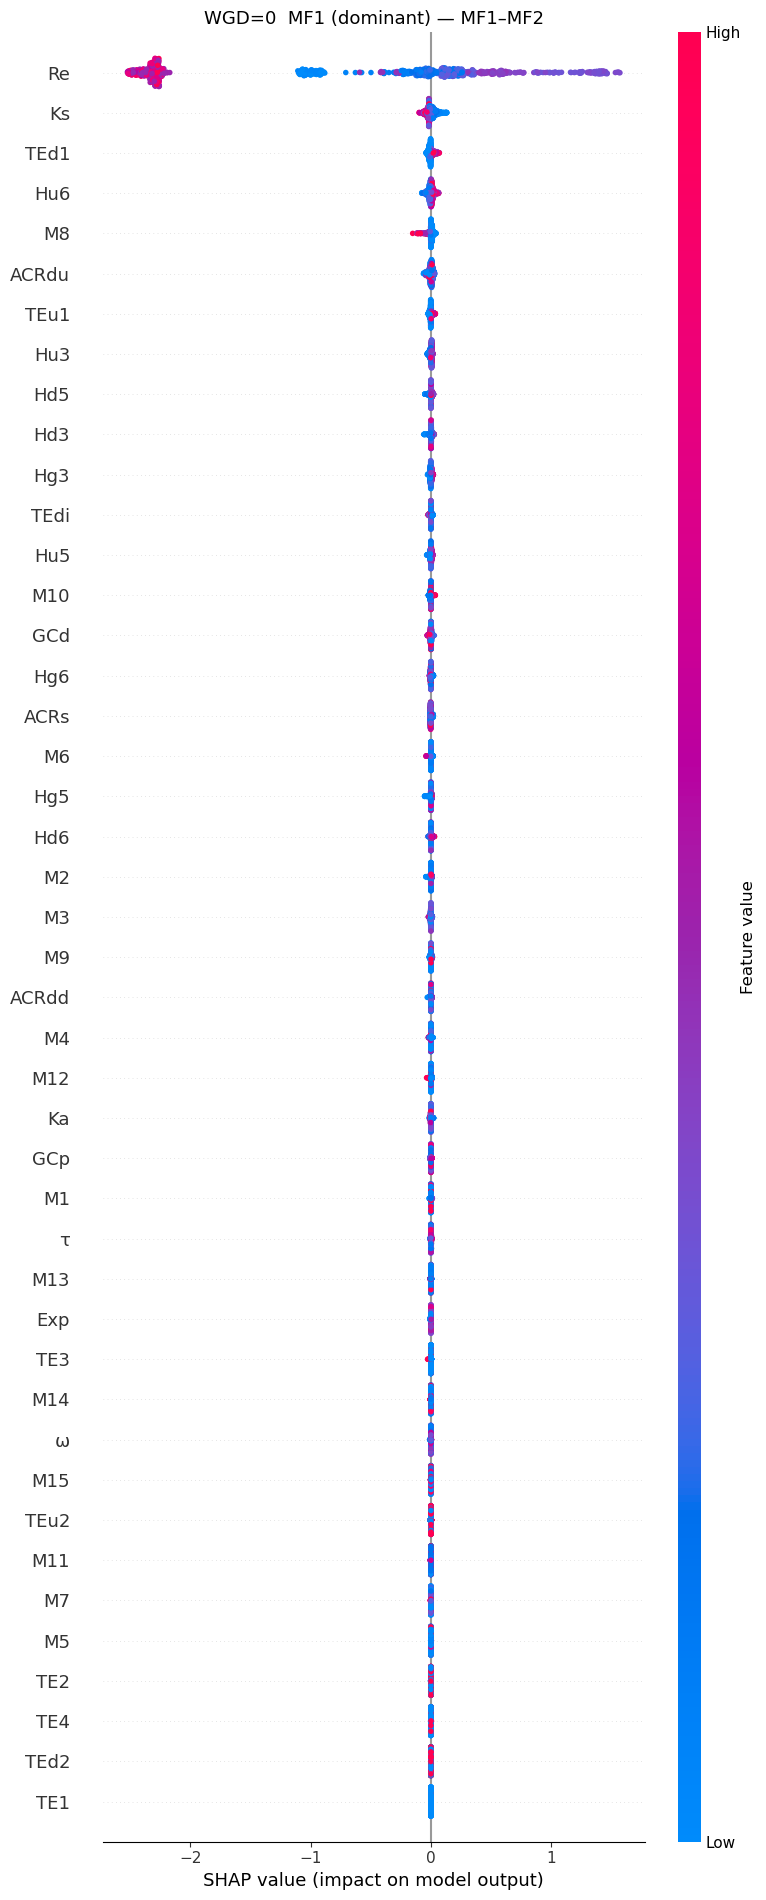

/scratch/local/31986664/ipykernel_1161982/558357326.py:57: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_groupI_shap_summary_label1.png


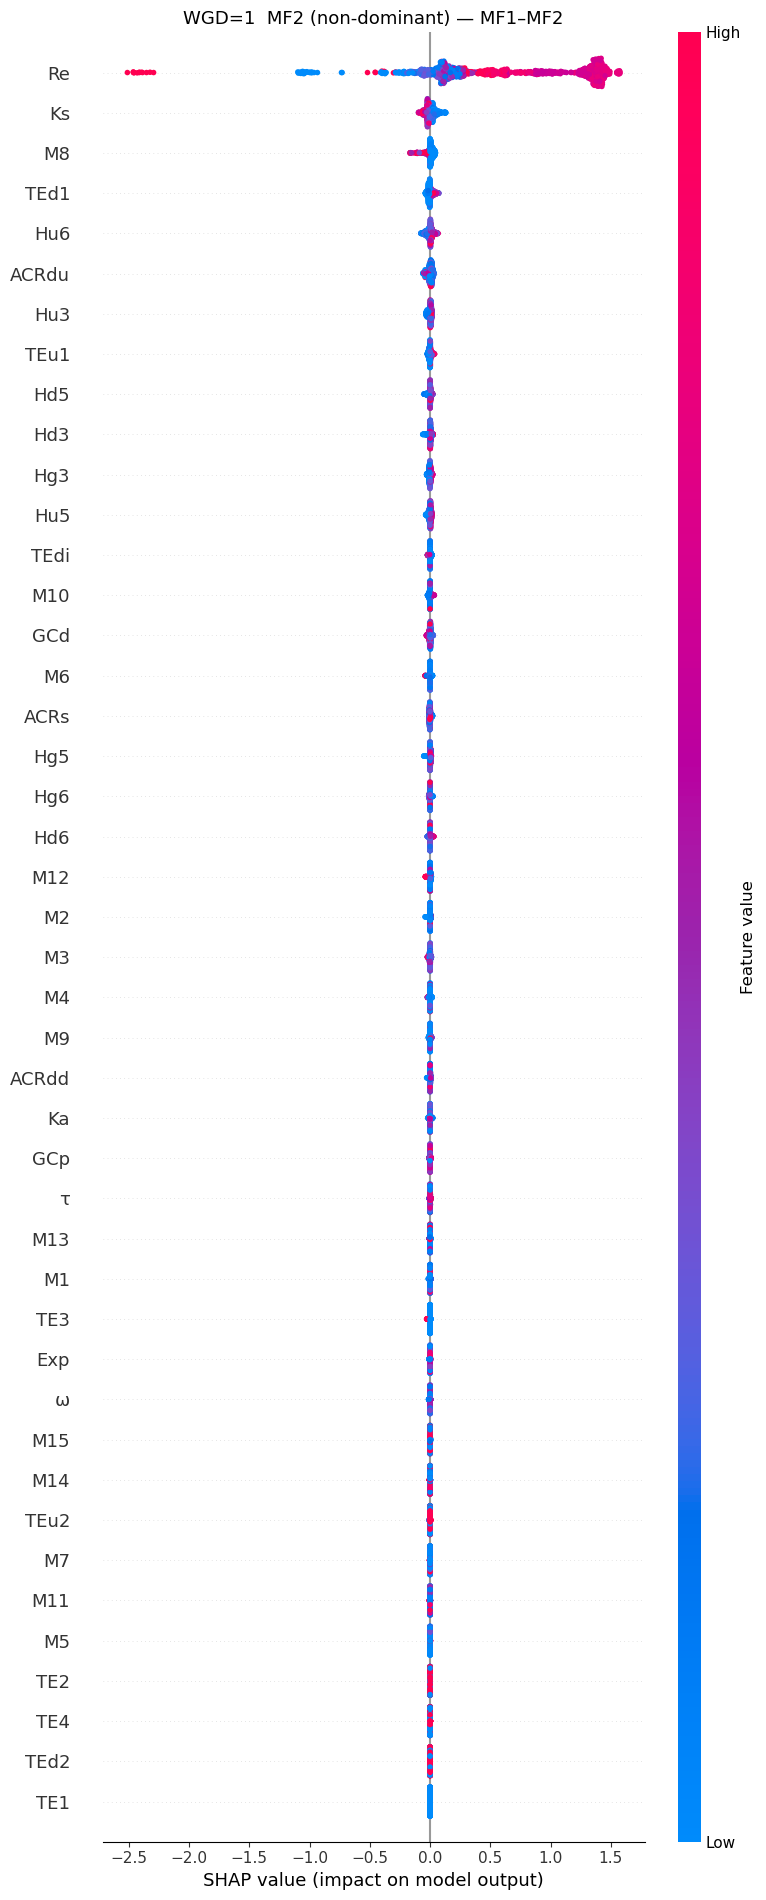

In [109]:
# ============================================================
# XAI CELL 5: SHAP SUMMARY PLOT — PER LABEL (BEESWARM)
# ============================================================
# Separate beeswarm plots for WGD=0 (dominant
# subgenome) and WGD=1 (non-dominant subgenome).
#
# Within each plot, features are ranked independently by
# mean absolute SHAP for that label's samples. Differences
# in rank order between plots reflect asymmetry in which
# features drive dominant vs. submissive classification —
# a core question in subgenome dominance research.
#
# Gray dots indicate NaN feature values (biologically
# meaningful for tau, upstream_distance, downstream_distance — 
# see Cell 1).
#
# X_test_label0/1 are the feature matrices for the same
# samples as shap_label0/1, extracted using the masks
# defined in XAI Cell 1.
# ============================================================

# --- Slice X_test_array to match per-label SHAP arrays ---
X_test_label0 = X_test_array[mask0]
X_test_label1 = X_test_array[mask1]

assert X_test_label0.shape[0] == shap_label0.shape[0], \
    "CRITICAL: X_test_label0 row count does not match shap_label0."
assert X_test_label1.shape[0] == shap_label1.shape[0], \
    "CRITICAL: X_test_label1 row count does not match shap_label1."

# --- WGD=0: dominant subgenome ---
shap.summary_plot(
    shap_label0,
    X_test_label0,
    feature_names = renamed_feature_names,
    max_display   = len(feature_names),
    show          = False,
)
plt.title(f"WGD=0  {SG0_LABEL} (dominant) — {PAIR_TITLE}", fontsize=13)
plt.tight_layout()

summary_label0_path = OUTPUT_DIR / f"{PREFIX}_shap_summary_label0.png"
plt.savefig(summary_label0_path, bbox_inches='tight', dpi=600)
print(f"Saved: {summary_label0_path}")
plt.show()
plt.close()

# --- WGD=1: non-dominant subgenome ---
shap.summary_plot(
    shap_label1,
    X_test_label1,
    feature_names = renamed_feature_names,
    max_display   = len(feature_names),
    show          = False,
)
plt.title(f"WGD=1  {SG1_LABEL} (non-dominant) — {PAIR_TITLE}", fontsize=13)
plt.tight_layout()

summary_label1_path = OUTPUT_DIR / f"{PREFIX}_shap_summary_label1.png"
plt.savefig(summary_label1_path, bbox_inches='tight', dpi=600)
print(f"Saved: {summary_label1_path}")
plt.show()
plt.close()

### Color-coded SHAP Bar Chart

Saved: /blue/meixiazhao/laylaaschuster/brapaGDM/final_models/model_outputs/mf1_mf2_groupI_shap_bar_chart.png


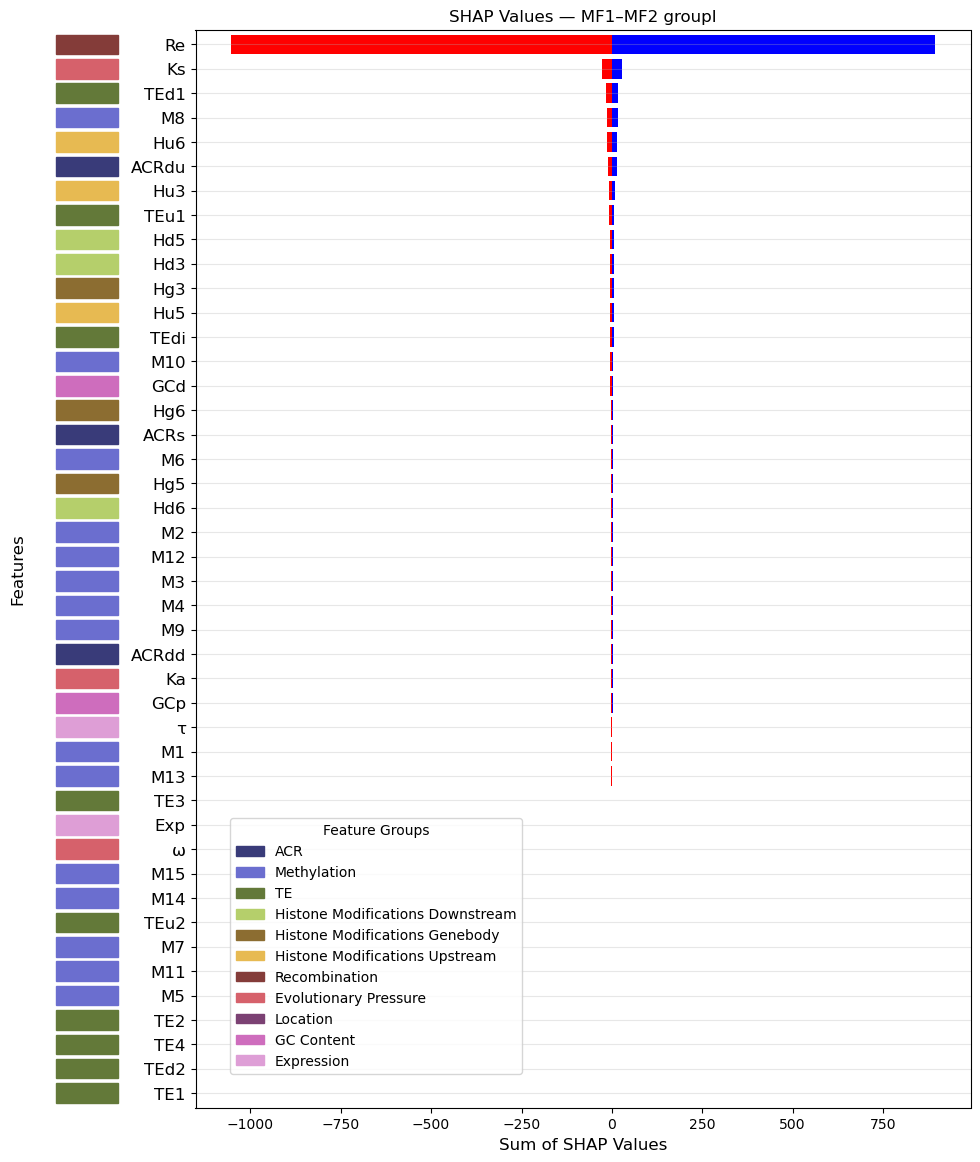

In [110]:
# ============================================================
# XAI CELL 6: COLOR-CODED SHAP BAR CHART (SUPPLEMENTAL)
# ============================================================
# Horizontal bar chart showing the sum of positive (blue) and
# negative (red) SHAP values per feature across all test-fold
# samples, sorted by total absolute SHAP magnitude (ascending,
# so highest-importance features appear at the top).
#
# Note: values are SUMMED across samples, not meaned. This
# reflects total directional contribution across the test set.
# For per-sample magnitude ranking, see the beeswarm plots
# (XAI Cells 4 and 5) and importance proportion (XAI Cell 3).
#
# Colored tiles on the left margin indicate feature group
# membership, consistent with network node colors (Cell 2).
# feature_rename_dict, feature_to_group, and group_to_color
# are defined in XAI Cell 2 — not redefined here.
# ============================================================

# --- Compute summed positive and negative SHAP per feature ---
positive_shap_values = np.sum(shap_vals * (shap_vals > 0), axis=0)
negative_shap_values = np.sum(shap_vals * (shap_vals < 0), axis=0)
absolute_shap_values = np.abs(positive_shap_values) + np.abs(negative_shap_values)

# --- Sort by total absolute SHAP (ascending) ---
sorted_indices = np.argsort(absolute_shap_values)
feature_names_arr = np.array(feature_names)

feature_names_sorted = feature_names_arr[sorted_indices]
positive_shap_values_sorted = positive_shap_values[sorted_indices]
negative_shap_values_sorted = negative_shap_values[sorted_indices]

# --- Build figure ---
fig, ax = plt.subplots(figsize=(10, 14))

y_positions = np.arange(len(feature_names_sorted))
ax.barh(y_positions, positive_shap_values_sorted, color='b', height=0.8)
ax.barh(y_positions, negative_shap_values_sorted, color='r', height=0.8)

# --- Draw Group Color Tiles ---
# We draw these directly on 'ax' using a specialized transform.
# This ensures they stay perfectly aligned with the Y-axis labels.
for i, feature in enumerate(feature_names_sorted):
    group = feature_to_group.get(feature, 'Other')
    color = group_to_color.get(group, 'gray')
    
    # rect: [x_start, y_start, width, height]
    # x is in axis coordinates (0=left, 1=right), y is in data coordinates
    rect = mpatches.Rectangle(
        (-0.18, y_positions[i] - 0.4),  # Starts 15% to the left of the plot
        0.08,                           # Width of the tile
        0.8,                            # Height (matches bar thickness)
        color=color, 
        transform=ax.get_yaxis_transform(), 
        clip_on=False
    )
    ax.add_patch(rect)

# --- Axis formatting ---
ax.set_xlabel('Sum of SHAP Values', fontsize=12)
ax.set_ylabel('Features', fontsize=12)

# Adjust label coords to make room for the tiles
ax.yaxis.set_label_coords(-0.22, 0.5) 
ax.set_title(f"SHAP Values — {PAIR_TITLE} {_group_tag}")

# Set tight limits to remove the extra vertical spacing
ax.set_ylim(-0.6, len(feature_names_sorted) - 0.4)

feature_rename_sorted = [feature_rename_dict.get(f, f) for f in feature_names_sorted]
ax.set_yticks(y_positions)
ax.set_yticklabels(feature_rename_sorted, fontsize=12)
ax.grid(True, axis='y', alpha=0.3)

# --- Group color legend ---
legend_patches = [
    mpatches.Patch(color=color, label=group) 
    for group, color in group_to_color.items()
]
ax.legend(handles=legend_patches, title="Feature Groups", bbox_to_anchor=(0.43, 0.15), loc='right')

# Save and show
bar_chart_path = OUTPUT_DIR / f"{PREFIX}_shap_bar_chart.png"
plt.savefig(bar_chart_path, bbox_inches='tight', dpi=600)
print(f"Saved: {bar_chart_path}")

plt.show()